## Import libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
# A function to create a dataset.
from sklearn.datasets import make_blobs 

# Output of plotting commands is displayed inline within the Jupyter notebook.
%matplotlib inline 

# Set a seed so that the results are consistent.
np.random.seed(3)

# 1. Single perceptron neural network with activation function

## 1.1 Create artificial data

Training dataset X containing (x1, x2) coordinates in the columns:
[[0 0 1 1 0 0 0 1 1 1 0 1 1 1 0 1 1 0 0 0 0 1 1 0 0 0 1 0 0 0]
 [0 1 0 1 1 0 1 0 0 1 1 0 0 1 0 1 0 1 1 1 1 0 1 0 0 1 1 1 0 0]]
Training dataset Y containing labels of two classes (0: blue, 1: red)
[[0 1 0 0 1 0 1 0 0 0 1 0 0 0 0 0 0 1 1 1 1 0 0 0 0 1 0 1 0 0]]
The shape of X is: (2, 30)
The shape of Y is: (1, 30)
I have m = 30 training examples!


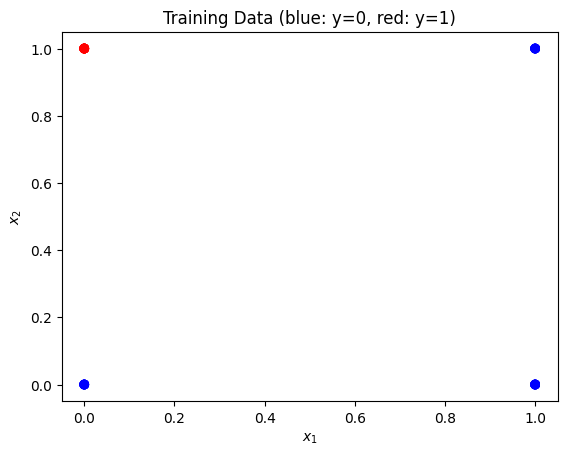

In [2]:
# Define sample size
m = 30


# 2 x 30 matrix of random 0 and 1
X = np.random.randint(0, 2, (2, m))

# Logical and operation
Y = np.logical_and(X[0] == 0, X[1] == 1).astype(int).reshape((1, m))

print('Training dataset X containing (x1, x2) coordinates in the columns:')
print(X)
print('Training dataset Y containing labels of two classes (0: blue, 1: red)')
print(Y)

print ('The shape of X is: ' + str(X.shape))
print ('The shape of Y is: ' + str(Y.shape))
print ('I have m = %d training examples!' % (X.shape[1]))

# -------------------------------------------------------------------------------------

fig, ax = plt.subplots()
ax.scatter(X[0, :], X[1, :], c=Y.flatten(), cmap=colors.ListedColormap(['blue', 'red']))
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_title('Training Data (blue: y=0, red: y=1)')
plt.show()

## 1.2 Defining model sizes

In [3]:
def layer_sizes(X, Y):
    """
    Arguments:
    X -- input dataset of shape (input size, number of examples)
    Y -- labels of shape (output size, number of examples)
    
    Returns:
    n_x -- the size of the input layer
    n_y -- the size of the output layer
    """
    n_x = X.shape[0]
    n_y = Y.shape[0]
    
    return (n_x, n_y)

(n_x, n_y) = layer_sizes(X, Y)
print("The size of the input layer is: n_x = " + str(n_x))
print("The size of the output layer is: n_y = " + str(n_y))

The size of the input layer is: n_x = 2
The size of the output layer is: n_y = 1


## 1.3 Initialize paramenters

In [4]:
np.random.seed(3)

def initialize_parameters(n_x, n_y): 
    """
    Returns:
    params -- python dictionary containing your parameters:
                    W -- weight matrix of shape (n_y, n_x)
                    b -- bias value set as a vector of shape (n_y, 1)
    """

    # Array of n_y x n_x size
    W =  np.random.randn(n_y, n_x) * 0.01

    # Array of biasses size n_y x 1
    b = np.zeros((n_y, 1))

    parameters = {"W": W,
                  "b": b}
    
    return parameters

parameters = initialize_parameters(n_x, n_y)
print("W = " + str(parameters["W"]))
print("b = " + str(parameters["b"]))

W = [[0.01788628 0.0043651 ]]
b = [[0.]]


## 1.4 Defining activation function 

In [5]:
# Define sigmoid function
def sigmoid(z):
    result = (1 + np.exp(-z))**(-1)

    return result

# --------------------------------------------------
# Testing function
print("sigmoid(-2) = " + str(sigmoid(-2)))
print("sigmoid(0) = " + str(sigmoid(0)))
print("sigmoid(3.5) = " + str(sigmoid(3.5)))

print('\nSigmoid of an array: ')
print(sigmoid(np.array([-2, 0, 3.5])))

sigmoid(-2) = 0.11920292202211755
sigmoid(0) = 0.5
sigmoid(3.5) = 0.9706877692486436

Sigmoid of an array: 
[0.11920292 0.5        0.97068777]


## 1.5 Forward propagation

In [10]:
def forward_propagation(X, parameters):
    """
    Argument:
    X -- input data of size (n_x, m)
    parameters -- python dictionary containing your parameters (output of initialization function)
    
    Returns:
    A -- The output
    """

    # Extracting parameters from dictionary 
    W = parameters['W']
    b = parameters['b']

    # Compute W X 
    Z = parameters['W'] @ X + b

    # Compute a 
    A = sigmoid(Z)

    return A


A = forward_propagation(X, parameters)

A

array([[0.5       , 0.50109127, 0.50447145, 0.50556262, 0.50109127,
        0.5       , 0.50109127, 0.50447145, 0.50447145, 0.50556262,
        0.50109127, 0.50447145, 0.50447145, 0.50556262, 0.5       ,
        0.50556262, 0.50447145, 0.50109127, 0.50109127, 0.50109127,
        0.50109127, 0.50447145, 0.50556262, 0.5       , 0.5       ,
        0.50109127, 0.50556262, 0.50109127, 0.5       , 0.5       ]])

## 1.6 Define cost function

In [9]:
def compute_cost(A, Y):
    """
    Computes the log loss cost function
    
    Arguments:
    A -- The output of the neural network of shape (n_y, number of examples)
    Y -- "true" labels vector of shape (n_y, number of examples)
    
    Returns:
    cost -- log loss
    
    """
    # Number of examples.
    m = Y.shape[1]

    # Compute the cost function.
    logprobs = - Y * np.log(A) - (1 - Y) * np.log(1 - A)

    cost = 1/m * np.sum(logprobs)
    
    return cost

print("cost = " + str(compute_cost(A, Y)))

cost = 0.6967540383027446


## 1.8 Calculate partial derivatives

In [11]:
def backward_propagation(A, X, Y):
    """
    Implements the backward propagation, calculating gradients
    
    Arguments:
    A -- the output of the neural network of shape (n_y, number of examples)
    X -- input data of shape (n_x, number of examples)
    Y -- "true" labels vector of shape (n_y, number of examples)
    
    Returns:
    grads -- python dictionary containing gradients with respect to different parameters
    """
    m = X.shape[1]
    
    # Backward propagation: calculate partial derivatives denoted as dW, db for simplicity. 
    dZ = A - Y
    dW = 1/m * np.dot(dZ, X.T)
    db = 1/m * np.sum(dZ, axis = 1, keepdims = True)
    
    grads = {"dW": dW,
             "db": db}
    
    return grads

grads = backward_propagation(A, X, Y)

print("dW = " + str(grads["dW"]))
print("db = " + str(grads["db"]))

dW = [[ 0.21882253 -0.06519039]]
db = [[0.16918629]]


In [12]:
def update_parameters(parameters, grads, learning_rate=1.2):
    """
    Updates parameters using the gradient descent update rule
    
    Arguments:
    parameters -- python dictionary containing parameters 
    grads -- python dictionary containing gradients 
    learning_rate -- learning rate parameter for gradient descent
    
    Returns:
    parameters -- python dictionary containing updated parameters 
    """
    # Retrieve each parameter from the dictionary "parameters".
    W = parameters["W"]
    b = parameters["b"]
    
    # Retrieve each gradient from the dictionary "grads".
    dW = grads["dW"]
    db = grads["db"]
    
    # Update rule for each parameter.
    W = W - learning_rate * dW
    b = b - learning_rate * db
    
    parameters = {"W": W,
                  "b": b}
    
    return parameters

parameters_updated = update_parameters(parameters, grads)

print("W updated = " + str(parameters_updated["W"]))
print("b updated = " + str(parameters_updated["b"]))

W updated = [[-0.24470075  0.08259356]]
b updated = [[-0.20302354]]


## 1.9 Neural network 

In [13]:
def nn_model(X, Y, num_iterations=10, learning_rate=1.2, print_cost=False):
    """
    Arguments:
    X -- dataset of shape (n_x, number of examples)
    Y -- labels of shape (n_y, number of examples)
    num_iterations -- number of iterations in the loop
    learning_rate -- learning rate parameter for gradient descent
    print_cost -- if True, print the cost every iteration
    
    Returns:
    parameters -- parameters learnt by the model. They can then be used to make predictions.
    """
    
    n_x = layer_sizes(X, Y)[0]
    n_y = layer_sizes(X, Y)[1]
    
    parameters = initialize_parameters(n_x, n_y)
    
    # Loop
    for i in range(0, num_iterations):
         
        # Forward propagation. Inputs: "X, parameters". Outputs: "A".
        A = forward_propagation(X, parameters)
        
        # Cost function. Inputs: "A, Y". Outputs: "cost".
        cost = compute_cost(A, Y)
        
        # Backpropagation. Inputs: "A, X, Y". Outputs: "grads".
        grads = backward_propagation(A, X, Y)
    
        # Gradient descent parameter update. Inputs: "parameters, grads, learning_rate". Outputs: "parameters".
        parameters = update_parameters(parameters, grads, learning_rate)
        
        # Print the cost every iteration.
        if print_cost:
            print ("Cost after iteration %i: %f" %(i, cost))

    return parameters

In [14]:
parameters = nn_model(X, Y, num_iterations=50, learning_rate=1.2, print_cost=True)
print("W = " + str(parameters["W"]))
print("b = " + str(parameters["b"]))

Cost after iteration 0: 0.694621
Cost after iteration 1: 0.611749
Cost after iteration 2: 0.557809
Cost after iteration 3: 0.516195
Cost after iteration 4: 0.481570
Cost after iteration 5: 0.451832
Cost after iteration 6: 0.425892
Cost after iteration 7: 0.403038
Cost after iteration 8: 0.382744
Cost after iteration 9: 0.364599
Cost after iteration 10: 0.348270
Cost after iteration 11: 0.333490
Cost after iteration 12: 0.320039
Cost after iteration 13: 0.307735
Cost after iteration 14: 0.296431
Cost after iteration 15: 0.286000
Cost after iteration 16: 0.276338
Cost after iteration 17: 0.267358
Cost after iteration 18: 0.258984
Cost after iteration 19: 0.251152
Cost after iteration 20: 0.243808
Cost after iteration 21: 0.236903
Cost after iteration 22: 0.230398
Cost after iteration 23: 0.224255
Cost after iteration 24: 0.218443
Cost after iteration 25: 0.212934
Cost after iteration 26: 0.207704
Cost after iteration 27: 0.202731
Cost after iteration 28: 0.197994
Cost after iteration 29:

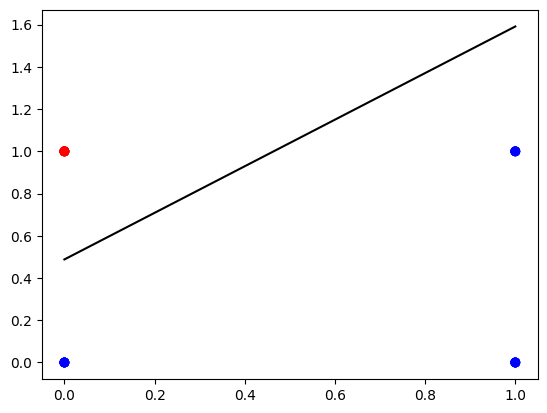

In [15]:
def plot_decision_boundary(X, Y, parameters):
    W = parameters["W"]
    b = parameters["b"]

    fig, ax = plt.subplots()
    plt.scatter(X[0, :], X[1, :], c=Y, cmap=colors.ListedColormap(['blue', 'red']))
    
    x_line = np.arange(np.min(X[0,:]),np.max(X[0,:])*1.1, 0.1)
    ax.plot(x_line, - W[0,0] / W[0,1] * x_line + -b[0,0] / W[0,1] , color="black")
    plt.plot()
    plt.show()
    
plot_decision_boundary(X, Y, parameters)

In [16]:
def predict(X, parameters):
    """
    Using the learned parameters, predicts a class for each example in X
    
    Arguments:
    parameters -- python dictionary containing your parameters 
    X -- input data of size (n_x, m)
    
    Returns
    predictions -- vector of predictions of our model (blue: False / red: True)
    """
    
    # Computes probabilities using forward propagation, and classifies to 0/1 using 0.5 as the threshold.
    A = forward_propagation(X, parameters)
    predictions = A > 0.5
    
    return predictions

X_pred = np.array([[1, 1, 0, 0],
                   [0, 1, 0, 1]])
Y_pred = predict(X_pred, parameters)

print(f"Coordinates (in the columns):\n{X_pred}")
print(f"Predictions:\n{Y_pred}")

Coordinates (in the columns):
[[1 1 0 0]
 [0 1 0 1]]
Predictions:
[[False False False  True]]
